# Product Reccomendation System

### EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## load dataset
df=pd.read_csv('rating_short.csv')
df.head()

,userid,productid,rating,date
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,1199750400
1,ALDXDYEGKB27G,B002L6HE9G,4.0,1331337600
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,1358640000
3,A23LX12CA3G4FG,B008HOEDYU,1.0,1385337600
4,A3TV7QFYXAG130,B0069R7TAM,5.0,1402963200


In [4]:
## size
df.shape

(78245, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78245 entries, 0 to 78244
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userid     78245 non-null  object 
 1   productid  78245 non-null  object 
 2   rating     78245 non-null  float64
 3   date       78245 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 2.4+ MB


In [6]:
## describe
df.describe()

,rating,date
count,78245.000000,7.824500e+04
mean,4.006454,1.338128e+09
std,1.385342,6.891994e+07
min,1.000000,9.320832e+08
25%,3.000000,1.315008e+09
50%,5.000000,1.360800e+09
75%,5.000000,1.386029e+09
max,5.000000,1.406074e+09


In [7]:
## missing values
df.isnull().sum()

userid       0
productid    0
rating       0
date         0
dtype: int64

In [8]:
## duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
##drop timestamp
df.drop('date',axis=1,inplace=True)

In [10]:
df.nunique()

userid       76430
productid    40228
rating           5
dtype: int64

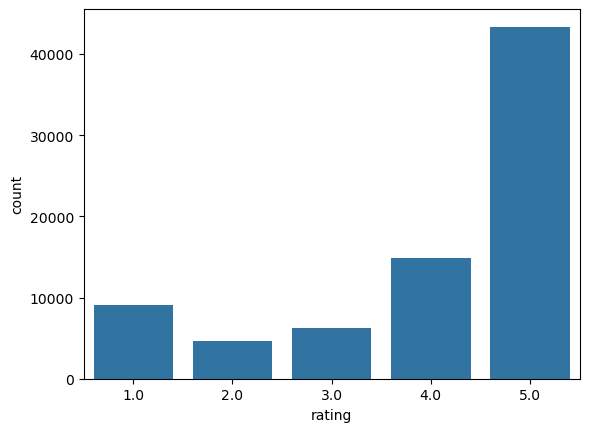

In [11]:
##rating distribution
sns.countplot(x='rating',data=df)
plt.show()

In [12]:
## user activity
user_count=df['userid'].value_counts()
print(user_count.describe())

count    76430.000000
mean         1.023747
std          0.177128
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          8.000000
Name: count, dtype: float64


In [13]:
# Top 10 active users
print(user_count.head(10))

userid
A3LGT6UZL99IW1    8
A1ODOGXEYECQQ8    8
ADLVFFE4VBT8      7
ARBKYIVNYWK3C     7
A27TN8D0CZ8LUY    6
AVPNQUVZWMDSX     6
A15QYHQH80W30L    6
A2AY4YUOX2N1BQ    6
A2J8T58Z4X15IO    5
A5JLAU2ARJ0BO     5
Name: count, dtype: int64


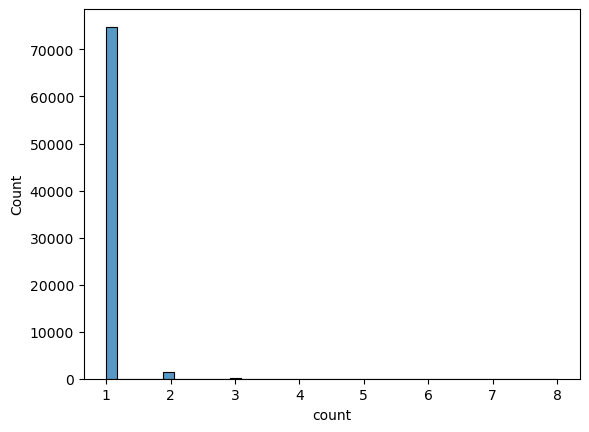

In [14]:
## rating per user
user_counts = df['userid'].value_counts()
sns.histplot(user_counts,bins=40)
plt.show()

In [15]:
## product popularity
product_count=df['productid'].value_counts()
print(product_count.describe())

count    40228.000000
mean         1.945038
std          3.766158
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        201.000000
Name: count, dtype: float64


In [16]:
# Top 10 popular products
print(product_count.head(10))

productid
B0074BW614    201
B00DR0PDNE    179
B007WTAJTO    147
B006GWO5WK    126
B003ELYQGG    126
B0019EHU8G    123
B00622AG6S    113
B008OHNZI0    112
B007R5YDYA    108
B003ES5ZUU    102
Name: count, dtype: int64


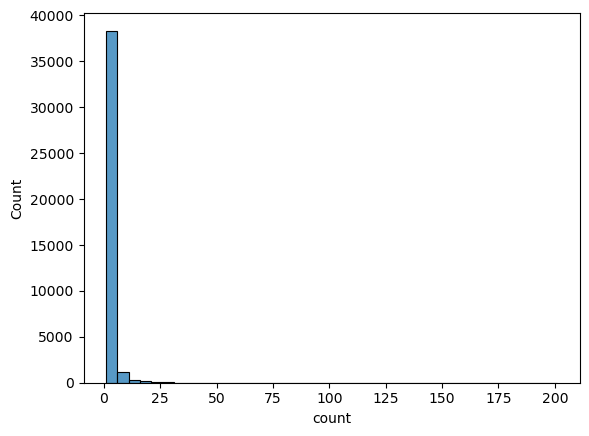

In [17]:
## rating per product
product_counts=df['productid'].value_counts()
sns.histplot(product_counts,bins=40)
plt.show()

In [18]:
##sparsity check
num_users = df['userid'].nunique()
num_products = df['productid'].nunique()
sparsity = 1 - (len(df) / (num_users * num_products))
print("Sparsity:", sparsity)

Sparsity: 0.999974551376661


In [19]:
## user product matrix
df_sample = df.sample(5000)
user_product_matrix = df_sample.pivot_table(
    index='userid',
    columns='productid',
    values='rating'
)
user_product_matrix.head()

productid,1400532655,140053271X,1615543570,9573212919,9625993428,9985673379,9985686764,B00000J1F3,B00000J1QN,B00000J3NG,...,B00JCZWUIO,B00JFKARAE,B00JIFMXSK,B00K133BQ6,B00KAKBHKM,B00KGGJPX6,B00KJ82D0I,B00KMRGF28,B00KWHMR6G,B00KZ40HT0
userid,,,,,,,,,,,,,,,,,,,,,
A00261423251DFHHYVST9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A03781433MOGB6PZVYN6Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A042274212BJJVOBS4Q85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A05244842UB93CWLZ8QCR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A06834701KP57LX2UJDZ0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
## product features
product_features = df.groupby('productid').agg({
    'rating': ['mean', 'count']})
product_features.columns = ['avg_rating', 'rating_count']
product_features.reset_index(inplace=True)
product_features.head()

,productid,avg_rating,rating_count
0,0594481813,5.000000,1
1,0972683275,4.428571,7
2,0983947600,5.000000,1
3,1400501466,5.000000,1
4,1400501776,5.000000,1


### Model Building

##### KMeans

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [22]:
X=product_features[['avg_rating','rating_count']]

In [23]:
std_sca=StandardScaler()
X_sca=std_sca.fit_transform(X)

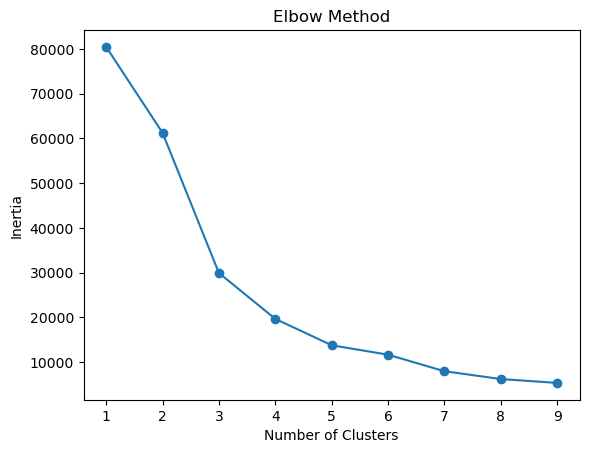

In [24]:
## elbow methode- to find best cluster
inertia=[]
for i in range(1,10):
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(X_sca)
    inertia.append(kmeans.inertia_)
plt.plot(range(1,10),inertia,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [25]:
# Based on elbow method, optimal K = 3
kmeans=KMeans(n_clusters=3,random_state=42)
product_features['km_cluster']=kmeans.fit_predict(X_sca)

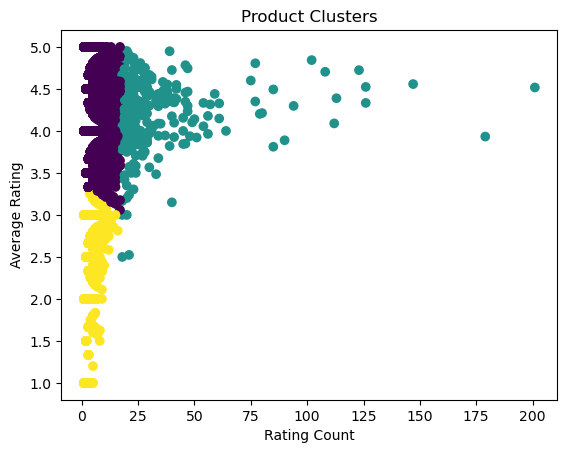

In [26]:
##visualize
plt.scatter(product_features['rating_count'],product_features['avg_rating'],
            c=product_features['km_cluster'])
plt.xlabel('Rating Count')
plt.ylabel('Average Rating')
plt.title('Product Clusters')
plt.show()

In [27]:
product_features.groupby('km_cluster')[['avg_rating', 'rating_count']].mean()

,avg_rating,rating_count
km_cluster,,
0,4.624971,1.829945
1,4.240414,32.641115
2,2.006777,1.431530


In [28]:
#Evaluation
score_kmeans=silhouette_score(X_sca,product_features['km_cluster'])
print(f'Silhouette Score:{score_kmeans}')

Silhouette Score:0.6477783856469254


##### Hierarchical

In [29]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage

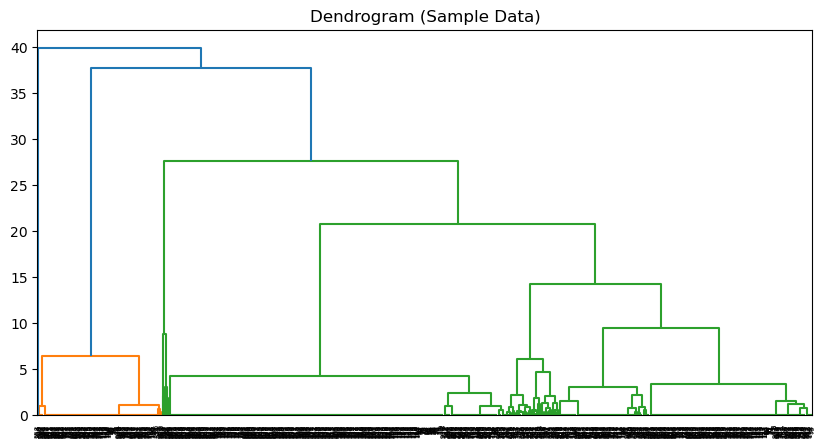

In [30]:
## visual cluster
sample_data = X_sca[np.random.choice(X_sca.shape[0], 1000, replace=False)]

linked = linkage(sample_data, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title('Dendrogram (Sample Data)')
plt.show()

In [31]:
##hierarchical
hc = AgglomerativeClustering(n_clusters=3)
product_features['hc_cluster'] = hc.fit_predict(X_sca)

In [32]:
## evaluation
score_hc = silhouette_score(X_sca, product_features['hc_cluster'])
print("Hierarchical Silhouette Score:", score_hc)

Hierarchical Silhouette Score: 0.657231115237227


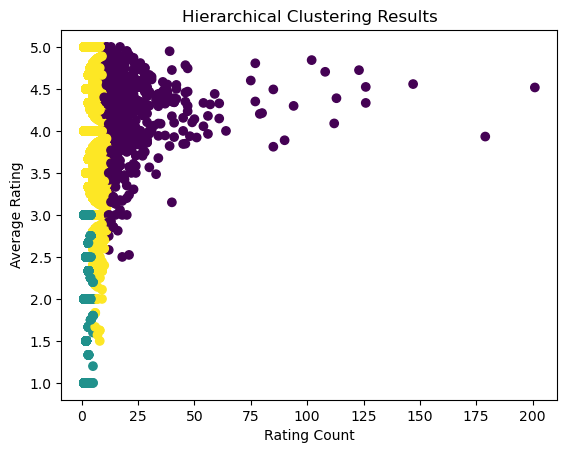

In [33]:
## visualization
plt.scatter(
    product_features['rating_count'],
    product_features['avg_rating'],
    c=product_features['hc_cluster']
)

plt.xlabel('Rating Count')
plt.ylabel('Average Rating')
plt.title('Hierarchical Clustering Results')
plt.show()

In [34]:
## cluster
product_features.groupby('hc_cluster')[['avg_rating', 'rating_count']].mean()

,avg_rating,rating_count
hc_cluster,,
0,4.233099,20.352708
1,1.980359,1.285673
2,4.613114,1.699699


##### DBScan

In [35]:
from sklearn.cluster import DBSCAN

In [36]:
dbscan=DBSCAN(eps=0.5,min_samples=5)
product_features['db_cluster'] = dbscan.fit_predict(X_sca)

In [37]:
##check clusters
product_features['db_cluster'].value_counts()

db_cluster
 0    40184
-1       31
 1       13
Name: count, dtype: int64

In [38]:
if len(set(product_features['db_cluster']))>1:
    score_db=silhouette_score(X_sca,product_features['db_cluster'])
    print("DBSCAN Silhouette Score:", score_db)
else:
    print("Not enough clusters for silhouette score")

DBSCAN Silhouette Score: 0.8880605493750037


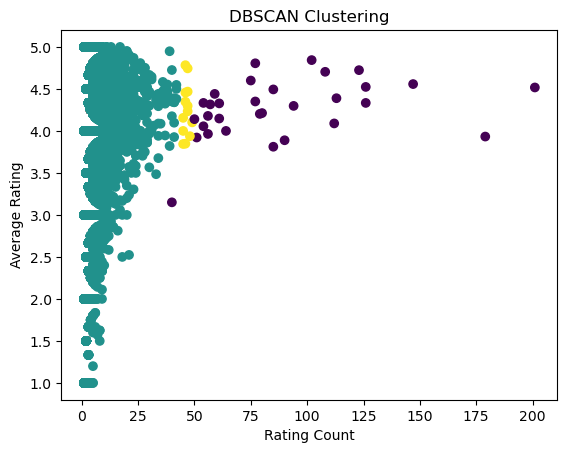

In [39]:
## visualize
import matplotlib.pyplot as plt

plt.scatter(
    product_features['rating_count'],
    product_features['avg_rating'],
    c=product_features['db_cluster']
)

plt.xlabel('Rating Count')
plt.ylabel('Average Rating')
plt.title('DBSCAN Clustering')
plt.show()

In [40]:
## cluster analysis
product_features.groupby('db_cluster')[['avg_rating', 'rating_count']].mean()

,avg_rating,rating_count
db_cluster,,
-1,4.266230,88.451613
0,3.933673,1.863901
1,4.247616,46.461538


In [41]:
#tuning
eps_values = [0.3,0.5,1.0]
min_samples_values = [3, 5, 10]
results = []
for eps in eps_values:
    for min_s in min_samples_values:
        
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_sca)
        
        # number of clusters (excluding noise)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        # count noise points
        noise = list(labels).count(-1)
        
        # silhouette score (only if valid)
        if n_clusters > 1:
            score = silhouette_score(X_sca, labels)
        else:
            score = -1
        
        results.append((eps, min_s, n_clusters, noise, score))

    

In [42]:
results_df = pd.DataFrame(results, columns=[
    'eps', 'min_samples', 'clusters', 'noise_points', 'silhouette_score'
])

print(results_df.sort_values(by='silhouette_score', ascending=False).head())

   eps  min_samples  clusters  noise_points  silhouette_score
7  1.0            5         2            15          0.933895
6  1.0            3         3            11          0.933819
3  0.5            3         3            26          0.889417
4  0.5            5         2            31          0.888061
5  0.5           10         5            37          0.847786


#### Comparison 

In [43]:
comparison = pd.DataFrame({
    'Model': ['KMeans', 'Hierarchical'],
    'Silhouette Score': [score_kmeans, score_hc]
})

comparison['Verdict'] = comparison['Silhouette Score'].apply(
    lambda x: 'Best' if x == comparison['Silhouette Score'].max() else 'Good'
)

comparison

,Model,Silhouette Score,Verdict
0,KMeans,0.647778,Good
1,Hierarchical,0.657231,Best


In [44]:
scores = {
    "KMeans": score_kmeans,
    "Hierarchical": score_hc
}

best_model = max(scores, key=scores.get)

print("Final Selected Model:", best_model)

Final Selected Model: Hierarchical


In [45]:
if best_model == "KMeans":
    cluster_col = 'km_cluster'
else:
    cluster_col = 'hc_cluster'

best_cluster = product_features.groupby(cluster_col)['avg_rating'].mean().idxmax()

In [53]:
def recommend_similar_products(product_id, top_n=5):
    if product_id not in product_features['productid'].values:
        return None

    cluster_id = product_features[
        product_features['productid'] == product_id
    ]['km_cluster'].values[0]

    similar_products = product_features[
        product_features['km_cluster'] == cluster_id
    ]

    similar_products = similar_products[
        similar_products['productid'] != product_id
    ]

    similar_products = similar_products.sort_values(
        by=['rating_count', 'avg_rating'],
        ascending=False
    )

    return similar_products[['productid', 'avg_rating', 'rating_count']].head(top_n)

In [54]:
recommended_products = product_features[
    product_features[cluster_col] == best_cluster
]


recommended_products = recommended_products.sort_values(
    by=['rating_count', 'avg_rating'],
    ascending=False
)

recommended_products.head(10)

,productid,avg_rating,rating_count,km_cluster,hc_cluster,db_cluster
14041,B002HWJT1A,4.000000,11,0,2,0
20928,B004CADY9I,4.000000,11,0,2,0
27352,B0069OAHUO,4.000000,11,0,2,0
31443,B008F05Q2E,4.000000,11,0,2,0
7694,B000TG4BA0,3.909091,11,0,2,0
10476,B001D7REIK,3.909091,11,0,2,0
13990,B002HJ9PTO,3.909091,11,0,2,0
35046,B00ARPLNYU,3.909091,11,0,2,0
537,B00005ARK3,3.818182,11,0,2,0
13652,B002CMLDT6,3.818182,11,0,2,0


In [55]:
recommend_similar_products('B0074BW614')

,productid,avg_rating,rating_count
37744,B00DR0PDNE,3.932961,179
30211,B007WTAJTO,4.557823,147
27588,B006GWO5WK,4.523810,126
17448,B003ELYQGG,4.333333,126
9970,B0019EHU8G,4.723577,123


In [56]:
# Save file for deployment

product_features.to_csv(r'C:\Users\Admin\Recommendation System Project\product_features.csv', index=False)

In [57]:
import os
print(os.getcwd())

C:\Users\Admin\Recommendation System Project
